In [1]:
# === 노트북 공통 preamble (llm_math 패키지 로드) ===
import sys
from pathlib import Path

# llm_math 패키지를 찾을 수 있는 후보 경로들
_candidates = [
    '.', 'src', '..', '../src',
    '/content/llm-math-book/src',
    '/content/llm-math-book',
    '/workspace/src',
    '/workspace',
]
# 현재 디렉토리의 상위 디렉토리들도 후보에 추가 (notebooks/ 폴더에서 실행 시)
for p in Path.cwd().parents:
    _candidates.append(str(p / 'src'))
    _candidates.append(str(p))

for p in _candidates:
    if p and p not in sys.path and Path(p).exists():
        sys.path.insert(0, p)

# llm_math import 시도
try:
    from llm_math import viz, bench, data
    _LLM_MATH_OK = True
except ImportError as e:
    _LLM_MATH_OK = False
    print(f"[주의] llm_math 패키지 로드 실패: {e}")
    print("  GitHub 레포를 클론하고 colab_setup.sh를 실행하세요.")
# === preamble 끝 ===


# Ch 02. 행렬과 선형변환 — 데이터의 재구성

> **학습 목표**
> - 행렬을 선형변환으로 이해한다
> - 행렬곱의 정의와 시간 복잡도 $O(n^3)$를 체감한다
> - CPU vs GPU에서 행렬곱 속도 차이를 직접 측정한다

## 2.1 행렬의 정의와 표기법

행렬(matrix)은 숫자들을 직사각형 형태로 배열한 것이다.

$$A = \begin{pmatrix} a_{11} & a_{12} & \cdots & a_{1n} \\ a_{21} & a_{22} & \cdots & a_{2n} \\ \vdots & & \ddots & \vdots \\ a_{m1} & a_{m2} & \cdots & a_{mn} \end{pmatrix} \in \mathbb{R}^{m \times n}$$

- $m$행 $n$열: $A \in \mathbb{R}^{m \times n}$
- $A_{ij}$: $i$번째 행, $j$번째 열 원소

LLM에서 가중치 행렬은 보통 $W \in \mathbb{R}^{d \times d}$ 형태다. $d=4096$이면 $W$는 1600만 개 원소.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from llm_math.viz import plot_heatmap

# 행렬 생성
A = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]], dtype=float)
print(f"A shape: {A.shape}")
print(f"A:\n{A}")
print(f"A^T (Transpose):\n{A.T}")

# 특수 행렬
I = np.eye(3)  # 단위 행렬
D = np.diag([1, 2, 3])  # 대각 행렬
print(f"\n단위 Matrix I:\n{I}")
print(f"\n대각 Matrix D:\n{D}")


A shape: (3, 3)
A:
[[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]]
A^T (Transpose):
[[1. 4. 7.]
 [2. 5. 8.]
 [3. 6. 9.]]

단위 Matrix I:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

대각 Matrix D:
[[1 0 0]
 [0 2 0]
 [0 0 3]]


## 2.2 행렬 연산

### 행렬 덧셈
$C = A + B$ where $C_{ij} = A_{ij} + B_{ij}$ (같은 shape 필요)

### 스칼라곱
$\alpha A$ where $(\alpha A)_{ij} = \alpha A_{ij}$

### 행렬곱 (Matrix Multiplication)
$$(AB)_{ij} = \sum_{k=1}^{n} A_{ik} B_{kj}$$

주의: $A \in \mathbb{R}^{m \times n}$, $B \in \mathbb{R}^{n \times p}$일 때만 정의. 결과는 $\mathbb{R}^{m \times p}$.

행렬곱의 시간 복잡도는 $O(mnp) \approx O(n^3)$ (정방행렬일 때). 이게 왜 중요한지 다음 벤치마크에서 본다.


In [3]:
# 행렬곱 직접 구현 vs np.dot
def matmul_naive(A, B):
    """3중 for문으로 Matrix곱 Implementation (느리지만 Principle 이해용)."""
    m, n = A.shape
    n2, p = B.shape
    assert n == n2, f"shape mismatch: {A.shape} vs {B.shape}"
    C = np.zeros((m, p))
    for i in range(m):
        for j in range(p):
            s = 0.0
            for k in range(n):
                s += A[i, k] * B[k, j]
            C[i, j] = s
    return C

A = np.random.randn(100, 100)
B = np.random.randn(100, 100)

# 직접 Implementation
C_naive = matmul_naive(A, B)
# NumPy
C_numpy = A @ B

# Result 동일 확인
print(f"최대 오차: {np.max(np.abs(C_naive - C_numpy)):.2e}")
print(f"두 Result가 같은가? {np.allclose(C_naive, C_numpy)}")


최대 오차: 1.78e-14
두 Result가 같은가? True


## 2.3 행렬을 통한 선형변환

행렬 $A \in \mathbb{R}^{n \times n}$는 벡터 $\mathbf{x} \in \mathbb{R}^n$를 다른 벡터 $\mathbf{y} = A\mathbf{x}$로 변환한다.

예시:
- **회전 행렬** (각 $\theta$): $R = \begin{pmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{pmatrix}$
- **스케일링**: $S = \mathrm{diag}(s_1, s_2)$
- **전단(shear)**: $H = \begin{pmatrix} 1 & k \\ 0 & 1 \end{pmatrix}$


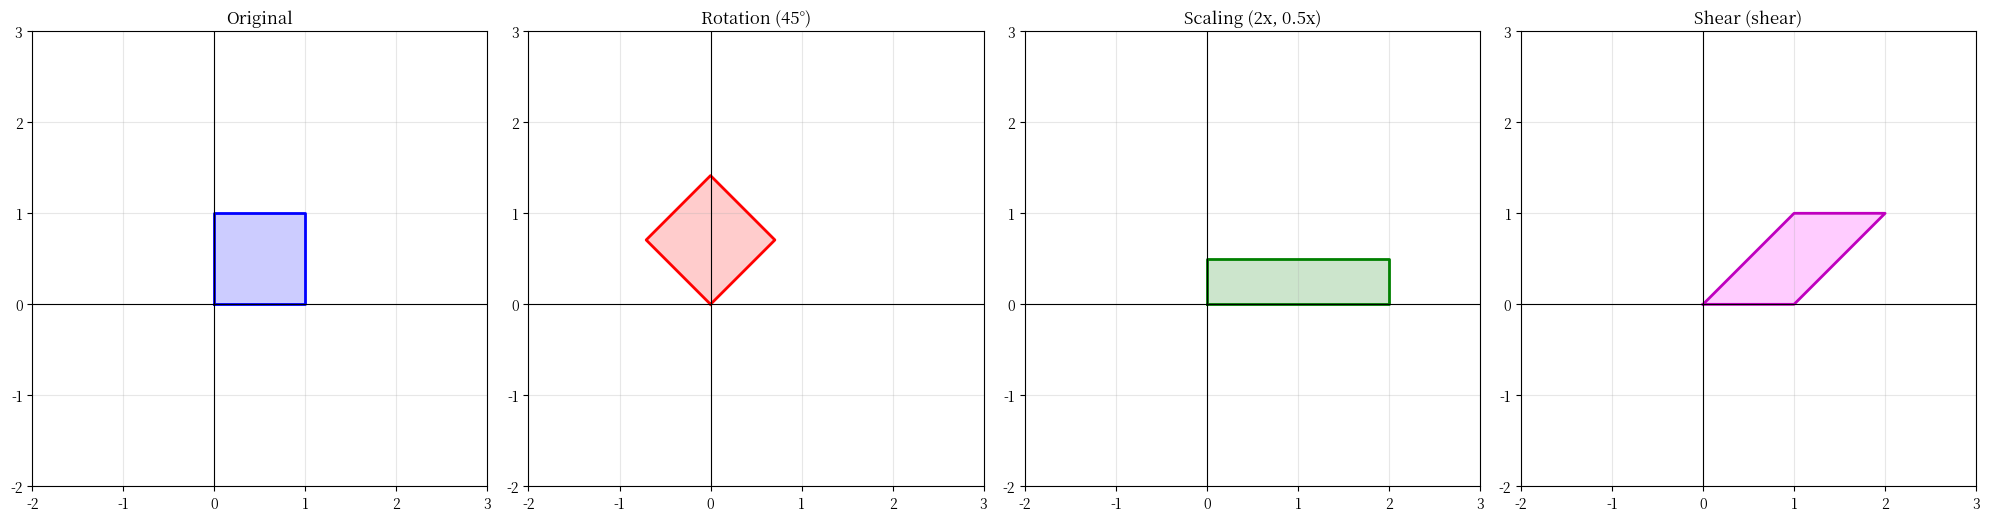

각 Matrix은 Space을 Transformation한다. Transformer의 모든 Weight Matrix도 이런 LinearTransformation이다.


In [4]:
# 선형변환 시각화
from llm_math.viz import plot_vector_2d, setup_axes_2d

theta = np.pi / 4  # 45도
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
S = np.array([[2, 0],
              [0, 0.5]])
H = np.array([[1, 1],
              [0, 1]])

# 원본 단위 정사각형의 꼭짓점
square = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]]).T  # (2, 5)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# 원본
ax = axes[0]
ax.plot(square[0], square[1], 'b-', linewidth=2)
ax.fill(square[0], square[1], alpha=0.2, color='blue')
setup_axes_2d(ax, xlim=(-2, 3), ylim=(-2, 3))
ax.set_title('Original')

# 회전
ax = axes[1]
sq_R = R @ square
ax.plot(sq_R[0], sq_R[1], 'r-', linewidth=2)
ax.fill(sq_R[0], sq_R[1], alpha=0.2, color='red')
setup_axes_2d(ax, xlim=(-2, 3), ylim=(-2, 3))
ax.set_title(f'Rotation (45°)')

# 스케일링
ax = axes[2]
sq_S = S @ square
ax.plot(sq_S[0], sq_S[1], 'g-', linewidth=2)
ax.fill(sq_S[0], sq_S[1], alpha=0.2, color='green')
setup_axes_2d(ax, xlim=(-2, 3), ylim=(-2, 3))
ax.set_title('Scaling (2x, 0.5x)')

# 전단
ax = axes[3]
sq_H = H @ square
ax.plot(sq_H[0], sq_H[1], 'm-', linewidth=2)
ax.fill(sq_H[0], sq_H[1], alpha=0.2, color='magenta')
setup_axes_2d(ax, xlim=(-2, 3), ylim=(-2, 3))
ax.set_title('Shear (shear)')

plt.tight_layout()
plt.savefig('../figures/ch02_linear_transforms.png', dpi=100, bbox_inches='tight')
plt.show()
print("각 Matrix은 Space을 Transformation한다. Transformer의 모든 Weight Matrix도 이런 LinearTransformation이다.")


## 2.4 역행렬과 그 의미

역행렬 $A^{-1}$는 변환을 되돌리는 행렬이다:
$$A^{-1} A = A A^{-1} = I$$

역행렬이 존재하려면 $\det(A) \neq 0$이어야 한다. 역행렬이 없으면 "특이(singular)"하다고 한다.


In [5]:
# 역행렬 예시
A = np.array([[2, 1],
              [1, 3]], dtype=float)
A_inv = np.linalg.inv(A)
print(f"A:\n{A}")
print(f"\nA^-1:\n{A_inv}")
print(f"\nA @ A^-1 (단위 Matrix이어야 함):\n{A @ A_inv}")

# 행렬식
det_A = np.linalg.det(A)
print(f"\ndet(A) = {det_A:.4f}")

# Singular Matrix 예시 (역Matrix 없음)
B = np.array([[1, 2],
              [2, 4]], dtype=float)  # 두 번째 행이 첫 번째 행의 2배
det_B = np.linalg.det(B)
print(f"\nB (특이 행렬):\n{B}")
print(f"det(B) = {det_B:.6f} (0이Plane 역Matrix 없음)")


A:
[[2. 1.]
 [1. 3.]]

A^-1:
[[ 0.6 -0.2]
 [-0.2  0.4]]

A @ A^-1 (단위 Matrix이어야 함):
[[ 1.00000000e+00  0.00000000e+00]
 [-5.55111512e-17  1.00000000e+00]]

det(A) = 5.0000

B (특이 행렬):
[[1. 2.]
 [2. 4.]]
det(B) = 0.000000 (0이Plane 역Matrix 없음)


## 2.5 고윳값·고유벡터와 대각화

정방행렬 $A$에 대해, 어떤 벡터 $\mathbf{v}$와 스칼라 $\lambda$는:
$$A \mathbf{v} = \lambda \mathbf{v}$$

이때 $\mathbf{v}$를 **고유벡터**, $\lambda$를 **고윳값**이라 한다.
고유벡터는 변환 $A$를 적용해도 **방향이 바뀌지 않는** 방향이다.

특이값 분해(SVD)는 모든 행렬에 대해 정의되는 분해:
$$A = U \Sigma V^\top$$

PCA(주성분 분석)의 수학적 기초.


In [6]:
# 고윳값/고유벡터
A = np.array([[4, -2],
              [1,  1]], dtype=float)
eigenvalues, eigenvectors = np.linalg.eig(A)
print(f"A:\n{A}")
print(f"\n고윳Value: {eigenvalues}")
print(f"EigenVector:\n{eigenvectors}")

# 검증: A v = lambda v
for i, (lam, v) in enumerate(zip(eigenvalues, eigenvectors.T)):
    Av = A @ v
    lv = lam * v
    print(f"\nEigenVector {i+1}: v = {v}, lambda = {lam:.4f}")
    print(f"  A @ v = {Av}")
    print(f"  lambda * v = {lv}")
    print(f"  일치? {np.allclose(Av, lv)}")


A:
[[ 4. -2.]
 [ 1.  1.]]

고윳Value: [3. 2.]
EigenVector:
[[0.89442719 0.70710678]
 [0.4472136  0.70710678]]

EigenVector 1: v = [0.89442719 0.4472136 ], lambda = 3.0000
  A @ v = [2.68328157 1.34164079]
  lambda * v = [2.68328157 1.34164079]
  일치? True

EigenVector 2: v = [0.70710678 0.70710678], lambda = 2.0000
  A @ v = [1.41421356 1.41421356]
  lambda * v = [1.41421356 1.41421356]
  일치? True


MNIST Data: (1000, 784)
U: (28, 28), s: (28,), Vt: (28, 28)
SingularValue (상위 10): [8.617033   3.822109   2.5613582  2.1886566  1.9993707  1.0997324
 0.8631734  0.78193384 0.46460277 0.41845757]


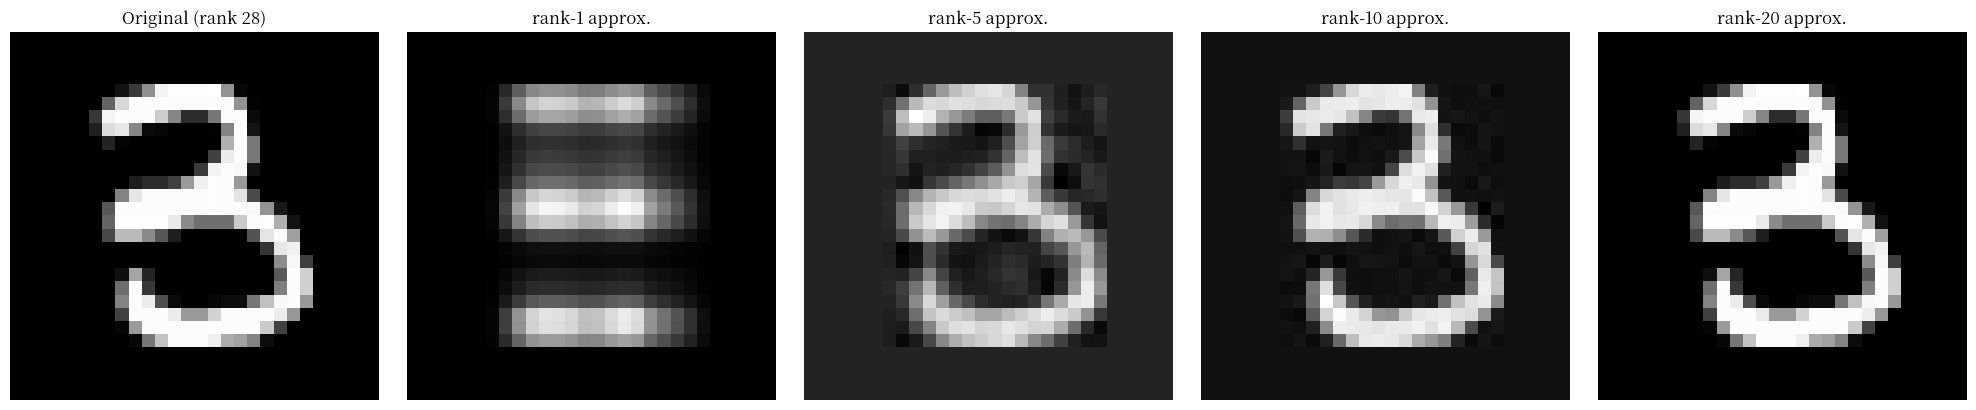


=> rank-10 approx.로도 숫자 모양이 보인다! SVD는 Data의 '핵심 정보'를 추출한다.


In [7]:
# SVD로 이미지 압축 (low-rank approximation)
from llm_math.data import load_mnist_small

X_train, y_train, _, _ = load_mnist_small(n_train=1000, n_test=100)
print(f"MNIST Data: {X_train.shape}")

# 첫 번째 이미지를 28x28로 reshape
img = X_train[0].reshape(28, 28)

# SVD
U, s, Vt = np.linalg.svd(img, full_matrices=False)
print(f"U: {U.shape}, s: {s.shape}, Vt: {Vt.shape}")
print(f"SingularValue (상위 10): {s[:10]}")

# rank-k 근사
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original (rank 28)')
axes[0].axis('off')

for i, k in enumerate([1, 5, 10, 20]):
    img_k = U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]
    axes[i+1].imshow(img_k, cmap='gray')
    axes[i+1].set_title(f'rank-{k} approx.')
    axes[i+1].axis('off')

plt.tight_layout()
plt.savefig('../figures/ch02_svd_compression.png', dpi=100, bbox_inches='tight')
plt.show()
print("\n=> rank-10 approx.로도 숫자 모양이 보인다! SVD는 Data의 '핵심 정보'를 추출한다.")


## 2.6 [CPU/GPU 벤치마크 ①] 행렬곱 크기별 속도 비교

행렬곱의 시간 복잡도는 $O(n^3)$이다. $n$이 2배 커지면 시간은 8배 증가한다.
CPU vs GPU에서 이 차이가 어떻게 나타나는지 직접 측정하자.


In [8]:
# 행렬곱 크기별 CPU vs GPU 벤치마크
import time
import numpy as np
from llm_math.bench import time_fn, format_results_table

try:
    import torch
    HAS_TORCH = True
except ImportError:
    HAS_TORCH = False
    print("PyTorch가 없어 NumPy CPU만 MeasurementSum니다.")

# 테스트할 행렬 크기
sizes = [64, 256, 512, 1024, 2048]

results = {}
print(f"{'n':>6} | {'NumPy CPU (ms)':>16} | {'Torch CPU (ms)':>16} | {'Torch GPU (ms)':>16} | {'Speedup (GPU/CPU)':>18}")
print("-" * 80)

for n in sizes:
    A_np = np.random.randn(n, n).astype(np.float32)
    B_np = np.random.randn(n, n).astype(np.float32)

    # NumPy CPU
    def np_matmul(A, B):
        return A @ B
    t_np = time_fn(np_matmul, A_np, B_np, device='cpu', warmup=2, repeat=3)['mean_ms']

    if HAS_TORCH:
        A_t = torch.from_numpy(A_np)
        B_t = torch.from_numpy(B_np)
        def t_matmul(A, B):
            return A @ B
        t_torch_cpu = time_fn(t_matmul, A_t, B_t, device='cpu', warmup=2, repeat=3)['mean_ms']

        if torch.cuda.is_available():
            A_gpu = A_t.cuda()
            B_gpu = B_t.cuda()
            t_torch_gpu = time_fn(t_matmul, A_gpu, B_gpu, device='cuda', warmup=3, repeat=5)['mean_ms']
            speedup = t_torch_cpu / t_torch_gpu if t_torch_gpu > 0 else float('inf')
            print(f"{n:>6} | {t_np:>16.3f} | {t_torch_cpu:>16.3f} | {t_torch_gpu:>16.3f} | {speedup:>17.2f}x")
        else:
            print(f"{n:>6} | {t_np:>16.3f} | {t_torch_cpu:>16.3f} | {'N/A':>16} | {'N/A':>18}")
    else:
        print(f"{n:>6} | {t_np:>16.3f} | {'N/A':>16} | {'N/A':>16} | {'N/A':>18}")

if not (HAS_TORCH and torch.cuda.is_available()):
    print("\n⚠ GPU가 감지되지 않았습니다. Colab에서 런타임을 T4 GPU로 전환하Plane 가속을 볼 수 있습니다.")
    print("  Runtime → Change runtime type → T4 GPU")


     n |   NumPy CPU (ms) |   Torch CPU (ms) |   Torch GPU (ms) |  Speedup (GPU/CPU)
--------------------------------------------------------------------------------
    64 |            0.007 |            0.007 |              N/A |                N/A
   256 |            0.169 |            9.092 |              N/A |                N/A
   512 |            1.226 |           10.950 |              N/A |                N/A


  1024 |           11.904 |           13.203 |              N/A |                N/A


  2048 |          122.058 |           99.768 |              N/A |                N/A

⚠ GPU가 감지되지 않았습니다. Colab에서 런타임을 T4 GPU로 전환하Plane 가속을 볼 수 있습니다.
  Runtime → Change runtime type → T4 GPU


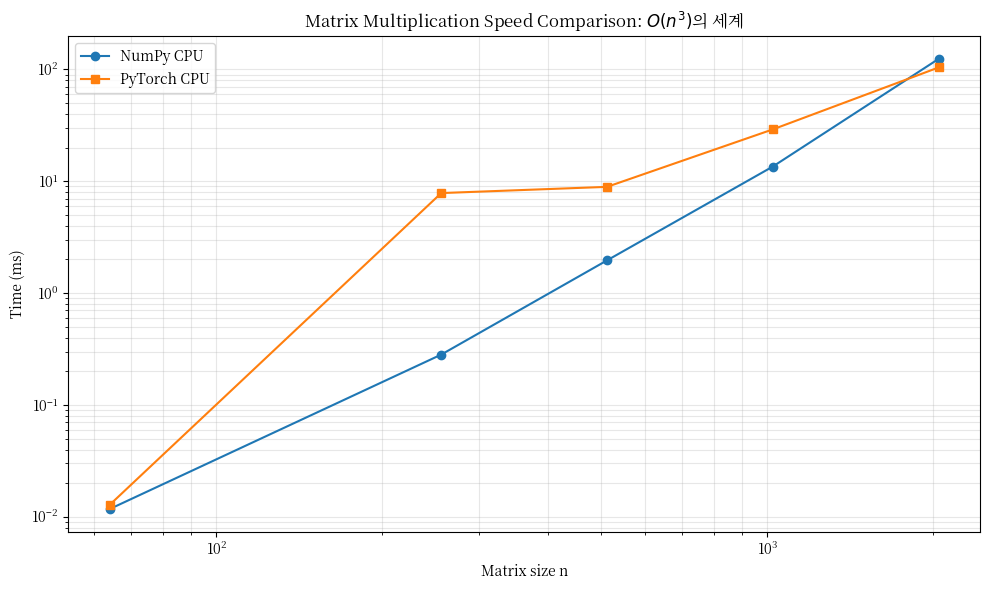

로그-로그 그래프에서 Gradient ≈ 3이Plane $O(n^3)$ Prediction과 일치!


In [9]:
# 시각화: 행렬 크기에 따른 시간 비교 (로그 스케일)
import matplotlib.pyplot as plt

# 위 셀에서 측정한 결과를 다시 수집 (이 셀 단독 실행용)
results_collect = {'n': [], 'numpy_cpu': [], 'torch_cpu': [], 'torch_gpu': []}
for n in [64, 256, 512, 1024, 2048]:
    A_np = np.random.randn(n, n).astype(np.float32)
    B_np = np.random.randn(n, n).astype(np.float32)
    t_np = time_fn(lambda A, B: A @ B, A_np, B_np, device='cpu', warmup=1, repeat=2)['mean_ms']
    results_collect['n'].append(n)
    results_collect['numpy_cpu'].append(t_np)
    if HAS_TORCH:
        A_t = torch.from_numpy(A_np); B_t = torch.from_numpy(B_np)
        t_tc = time_fn(lambda A, B: A @ B, A_t, B_t, device='cpu', warmup=1, repeat=2)['mean_ms']
        results_collect['torch_cpu'].append(t_tc)
        if torch.cuda.is_available():
            A_g = A_t.cuda(); B_g = B_t.cuda()
            t_tg = time_fn(lambda A, B: A @ B, A_g, B_g, device='cuda', warmup=2, repeat=3)['mean_ms']
            results_collect['torch_gpu'].append(t_tg)
        else:
            results_collect['torch_gpu'].append(None)
    else:
        results_collect['torch_cpu'].append(None)
        results_collect['torch_gpu'].append(None)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(results_collect['n'], results_collect['numpy_cpu'], 'o-', label='NumPy CPU')
if results_collect['torch_cpu'][0] is not None:
    ax.plot(results_collect['n'], results_collect['torch_cpu'], 's-', label='PyTorch CPU')
if results_collect['torch_gpu'][0] is not None:
    ax.plot(results_collect['n'], results_collect['torch_gpu'], '^-', label='PyTorch GPU', linewidth=2)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Matrix size n')
ax.set_ylabel('Time (ms)')
ax.set_title('Matrix Multiplication Speed Comparison: $O(n^3)$의 세계')
ax.legend()
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('../figures/ch02_bench_matmul.png', dpi=100, bbox_inches='tight')
plt.show()
print("로그-로그 그래프에서 Gradient ≈ 3이Plane $O(n^3)$ Prediction과 일치!")


## 2.7 핵심 정리

| 개념 | 수식 | 의미 |
|---|---|---|
| 행렬곱 | $(AB)_{ij} = \sum_k A_{ik}B_{kj}$ | 선형변환의 합성, $O(n^3)$ |
| 전치 | $(A^\top)_{ij} = A_{ji}$ | 행/열 교환 |
| 역행렬 | $A^{-1}A = I$ | 변환 되돌리기 (det≠0) |
| 고유분해 | $A\mathbf{v} = \lambda\mathbf{v}$ | 방향 보존 벡터 |
| SVD | $A = U\Sigma V^\top$ | 모든 행렬에 대한 분해 |

## 연습문제

1. $A = \begin{pmatrix} 1 & 2 \\ 3 & 4 \end{pmatrix}$, $B = \begin{pmatrix} 5 & 6 \\ 7 & 8 \end{pmatrix}$에 대해 $AB$와 $BA$를 계산하고, 행렬곱이 교환법칙이 성립하지 않음을 확인하라.
2. 100x100 랜덤 행렬의 역행렬을 구하고 $AA^{-1} = I$임을 확인하라.
3. 회전 행렬 $R(\theta)$의 역행렬은 $R(-\theta)$임을 수치적으로 확인하라.
4. SVD에서 rank-k 근사의 재구성 오차 $\|A - A_k\|_F$가 상위 k개 특이값 제곱합의 합과 같음을 확인하라.
5. 행렬곱이 $O(n^3)$인 이유를 설명하라. n=4096일 때 예상 시간을 n=1024일 때 기반으로 추정하라.

> 해설: `solutions/ch02_solutions.ipynb`
